# S4/S5 · AndinaLog · Notebook 3 · Interpretación de conductores

Este notebook **solo lee** `andinalog_hr_drivers_silver.csv`, generado por el notebook 2. Calcula estadísticas descriptivas, presenta gráficos y genera una síntesis descriptiva automática para comparar centros de distribución. No vuelve a curar datos, no modifica Silver y no exporta nombres ni resultados individuales.

**Alcance:** una fotografía del mes representado en el archivo. No hay fechas por registro ni historial mensual para analizar tendencias. Las asociaciones y diferencias entre centros no demuestran causas ni sirven para evaluar a una persona. Como solo lee Silver, no cuantifica el efecto de las filas excluidas de ese archivo.


## 1 · Carga local o desde Drive

En local, ejecuta este notebook desde cualquier carpeta dentro de `practicasNotebookColab`. En Colab, ajusta `RUTA_PROYECTO_DRIVE` a la carpeta que contiene `S4/` y monta Drive.


In [2]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

ENTORNO = "auto"  # "auto", "local" o "drive"
RUTA_PROYECTO_DRIVE = "/content/drive/MyDrive/GIAD"
NOMBRE_SILVER = "andinalog_hr_drivers_silver.csv"
COLUMNAS_SILVER = [
    "chofer_id", "centro_distribucion", "horas_conduccion_mes",
    "salario_base_bob", "ausentismo_dias",
]
COLUMNAS_NUMERICAS = ["horas_conduccion_mes", "salario_base_bob", "ausentismo_dias"]

def encontrar_raiz_local():
    for carpeta in [Path.cwd(), *Path.cwd().parents]:
        if (carpeta / "S4" / "andinalog_hr_drivers" / "notebook2" / "salidas" / NOMBRE_SILVER).is_file():
            return carpeta
    raise FileNotFoundError("No se encontró Silver. Ejecuta dentro del proyecto después del notebook 2.")

def obtener_ruta_silver():
    entorno = ENTORNO
    if entorno == "auto":
        entorno = "drive" if "google.colab" in sys.modules else "local"
    if entorno == "drive":
        from google.colab import drive
        drive.mount("/content/drive")
        raiz = Path(RUTA_PROYECTO_DRIVE)
    elif entorno == "local":
        raiz = encontrar_raiz_local()
    else:
        raise ValueError("ENTORNO debe ser 'auto', 'local' o 'drive'")
    ruta = raiz / "S4" / "andinalog_hr_drivers" / "notebook2" / "salidas" / NOMBRE_SILVER
    if not ruta.is_file():
        raise FileNotFoundError(f"No se encontró Silver: {ruta}")
    return ruta

RUTA_SILVER = obtener_ruta_silver()
print("Silver:", RUTA_SILVER)


Silver: c:\Users\remrodri\Github\practicasNotebookColab\S4\andinalog_hr_drivers\notebook2\salidas\andinalog_hr_drivers_silver.csv


## 2 · Contrato de entrada y preparación para cálculos

Las conversiones numéricas ocurren **solo en memoria** para calcular estadísticas. Si Silver contiene columnas o valores inesperados, el análisis se detiene: este notebook no corrige datos.


In [3]:
df_silver_raw = pd.read_csv(RUTA_SILVER, dtype="string", encoding="utf-8-sig", keep_default_na=False)
if list(df_silver_raw.columns) != COLUMNAS_SILVER:
    raise ValueError(f"Esquema Silver inesperado: {list(df_silver_raw.columns)}")
if df_silver_raw.empty:
    raise ValueError("Silver está vacío")
if df_silver_raw["chofer_id"].str.strip().eq("").any() or df_silver_raw["chofer_id"].duplicated().any():
    raise ValueError("Silver contiene identificadores vacíos o duplicados")
if df_silver_raw["centro_distribucion"].str.strip().eq("").any():
    raise ValueError("Silver contiene centros vacíos")
assert "chofer_nombre" not in df_silver_raw.columns

df = df_silver_raw.copy(deep=True)
for columna in COLUMNAS_NUMERICAS:
    df[columna] = pd.to_numeric(df[columna].str.strip(), errors="raise")
if df[COLUMNAS_NUMERICAS].isna().any().any():
    raise ValueError("Silver contiene valores numéricos faltantes")
if (df["horas_conduccion_mes"] < 0).any() or (df["salario_base_bob"] <= 0).any():
    raise ValueError("Silver contiene horas negativas o salarios no positivos")
if (df["ausentismo_dias"] < 0).any() or (df["ausentismo_dias"] % 1 != 0).any():
    raise ValueError("Silver contiene días de ausentismo negativos o no enteros")

print(f"Conductores únicos: {len(df):,}")
print(f"Centros: {df['centro_distribucion'].nunique()}")
print("Columnas disponibles:", ", ".join(df.columns))


Conductores únicos: 146
Centros: 5
Columnas disponibles: chofer_id, centro_distribucion, horas_conduccion_mes, salario_base_bob, ausentismo_dias


## 3 · Estadísticas generales

La media describe el promedio; la mediana y los percentiles muestran la distribución con menos sensibilidad a valores extremos. `ausentismo_dias` es el total reportado en el archivo, no una tasa de ausentismo respecto a días programados, porque ese denominador no está disponible.


In [4]:
resumen_general = df[COLUMNAS_NUMERICAS].describe(percentiles=[0.25, 0.5, 0.75]).T
resumen_general = resumen_general.rename(columns={"count":"conductores","mean":"media","std":"desv_est","min":"minimo","25%":"p25","50%":"mediana","75%":"p75","max":"maximo"})
resumen_general = resumen_general[["conductores","media","mediana","desv_est","minimo","p25","p75","maximo"]]
display(resumen_general.round(2))


,conductores,media,mediana,desv_est,minimo,p25,p75,maximo
horas_conduccion_mes,146.0,159.12,161.5,28.65,77.3,138.57,180.52,224.6
salario_base_bob,146.0,5027.11,4952.4,903.36,3508.43,4223.19,5934.5,6492.63
ausentismo_dias,146.0,0.49,0.0,0.97,0.0,0.0,1.0,5.0


## 4 · Comparación entre centros

Se muestran simultáneamente el número de conductores y las medidas por centro. La proporción con alguna ausencia permite comparar centros de distinto tamaño, pero siempre se presenta junto con su numerador y denominador. No mide severidad ni días programados.


In [5]:
def resumir_centros(datos):
    tabla = datos.groupby("centro_distribucion", sort=True).agg(
        conductores=("chofer_id", "nunique"),
        horas_media=("horas_conduccion_mes", "mean"),
        horas_mediana=("horas_conduccion_mes", "median"),
        salario_medio_bob=("salario_base_bob", "mean"),
        salario_mediano_bob=("salario_base_bob", "median"),
        ausentismo_dias_medio=("ausentismo_dias", "mean"),
        conductores_con_ausencia=("ausentismo_dias", lambda s: int(s.gt(0).sum())),
    )
    tabla["pct_con_alguna_ausencia"] = 100 * tabla["conductores_con_ausencia"] / tabla["conductores"]
    tabla["con_ausencia_n_de_N"] = [
        f"{int(con_ausencia)}/{int(total)}"
        for con_ausencia, total in zip(tabla["conductores_con_ausencia"], tabla["conductores"])
    ]
    return tabla.sort_values("conductores", ascending=False)

tabla_centros = resumir_centros(df)
assert tabla_centros["conductores"].sum() == len(df)
assert tabla_centros["conductores_con_ausencia"].le(tabla_centros["conductores"]).all()
display(tabla_centros.round(2))


,conductores,horas_media,horas_mediana,salario_medio_bob,salario_mediano_bob,ausentismo_dias_medio,conductores_con_ausencia,pct_con_alguna_ausencia,con_ausencia_n_de_N
centro_distribucion,,,,,,,,,
Santa Cruz,47,159.8,160.3,4880.04,4714.74,0.66,17,36.17,17/47
Cochabamba,36,164.36,166.2,5003.98,5050.79,0.31,6,16.67,6/36
La Paz,30,153.24,150.8,5159.13,5275.28,0.53,8,26.67,8/30
Tarija,19,166.26,172.7,4978.76,4887.8,0.26,5,26.32,5/19
Oruro,14,146.25,147.75,5363.01,5505.32,0.64,7,50.0,7/14


In [6]:
def redactar_sintesis_descriptiva(datos, tabla):
    n = len(datos)
    total_centros = len(tabla)
    con_ausencia = int(datos["ausentismo_dias"].gt(0).sum())
    centro_mas_horas = tabla["horas_mediana"].idxmax()
    centro_menos_horas = tabla["horas_mediana"].idxmin()
    centro_mas_ausencia = tabla["pct_con_alguna_ausencia"].idxmax()
    centro_menor_muestra = tabla["conductores"].idxmin()
    fila_ausencia = tabla.loc[centro_mas_ausencia]
    texto = [
        f"ALCANCE: se analizaron {n} conductores utilizables de {total_centros} centros. "
        "Este archivo Silver no incluye las filas en cuarentena; por tanto, el análisis no mide "
        "cómo cambiarían los resultados si esas filas se resolvieran.",
        f"HORAS: la mediana más alta aparece en {centro_mas_horas} "
        f"({tabla.loc[centro_mas_horas, 'horas_mediana']:.1f} h) y la más baja en "
        f"{centro_menos_horas} ({tabla.loc[centro_menos_horas, 'horas_mediana']:.1f} h).",
        f"AUSENTISMO: {con_ausencia} de {n} conductores ({100 * con_ausencia / n:.1f} %) "
        "registraron al menos un día de ausencia. "
        f"El porcentaje más alto por centro aparece en {centro_mas_ausencia}: "
        f"{int(fila_ausencia['conductores_con_ausencia'])} de {int(fila_ausencia['conductores'])} "
        f"({fila_ausencia['pct_con_alguna_ausencia']:.1f} %).",
        f"TAMAÑO DE GRUPO: {centro_menor_muestra} tiene la muestra más pequeña "
        f"(n={int(tabla.loc[centro_menor_muestra, 'conductores'])}); sus porcentajes deben leerse "
        "con ese tamaño de grupo en mente.",
        "LÍMITE: estas cifras describen asociaciones y diferencias observadas. No demuestran "
        "causas, desempeño individual ni una tasa de ausentismo respecto a días programados.",
    ]
    return "\n\n".join(texto)

sintesis_descriptiva = redactar_sintesis_descriptiva(df, tabla_centros)
print(sintesis_descriptiva)


ALCANCE: se analizaron 146 conductores utilizables de 5 centros. Este archivo Silver no incluye las filas en cuarentena; por tanto, el análisis no mide cómo cambiarían los resultados si esas filas se resolvieran.

HORAS: la mediana más alta aparece en Tarija (172.7 h) y la más baja en Oruro (147.8 h).

AUSENTISMO: 43 de 146 conductores (29.5 %) registraron al menos un día de ausencia. El porcentaje más alto por centro aparece en Oruro: 7 de 14 (50.0 %).

TAMAÑO DE GRUPO: Oruro tiene la muestra más pequeña (n=14); sus porcentajes deben leerse con ese tamaño de grupo en mente.

LÍMITE: estas cifras describen asociaciones y diferencias observadas. No demuestran causas, desempeño individual ni una tasa de ausentismo respecto a días programados.


## 5 · Gráficos de distribución y comparación

Los diagramas de caja muestran dispersión sin identificar personas. Las barras de ausencia muestran porcentajes; el tamaño de cada centro aparece junto al nombre para evitar comparar proporciones sin contexto.


C:\Users\remrodri\AppData\Local\Temp\ipykernel_27164\2247646661.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,1].boxplot(series_horas, labels=orden, showfliers=True)
C:\Users\remrodri\AppData\Local\Temp\ipykernel_27164\2247646661.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,0].boxplot(series_salario, labels=orden, showfliers=True)


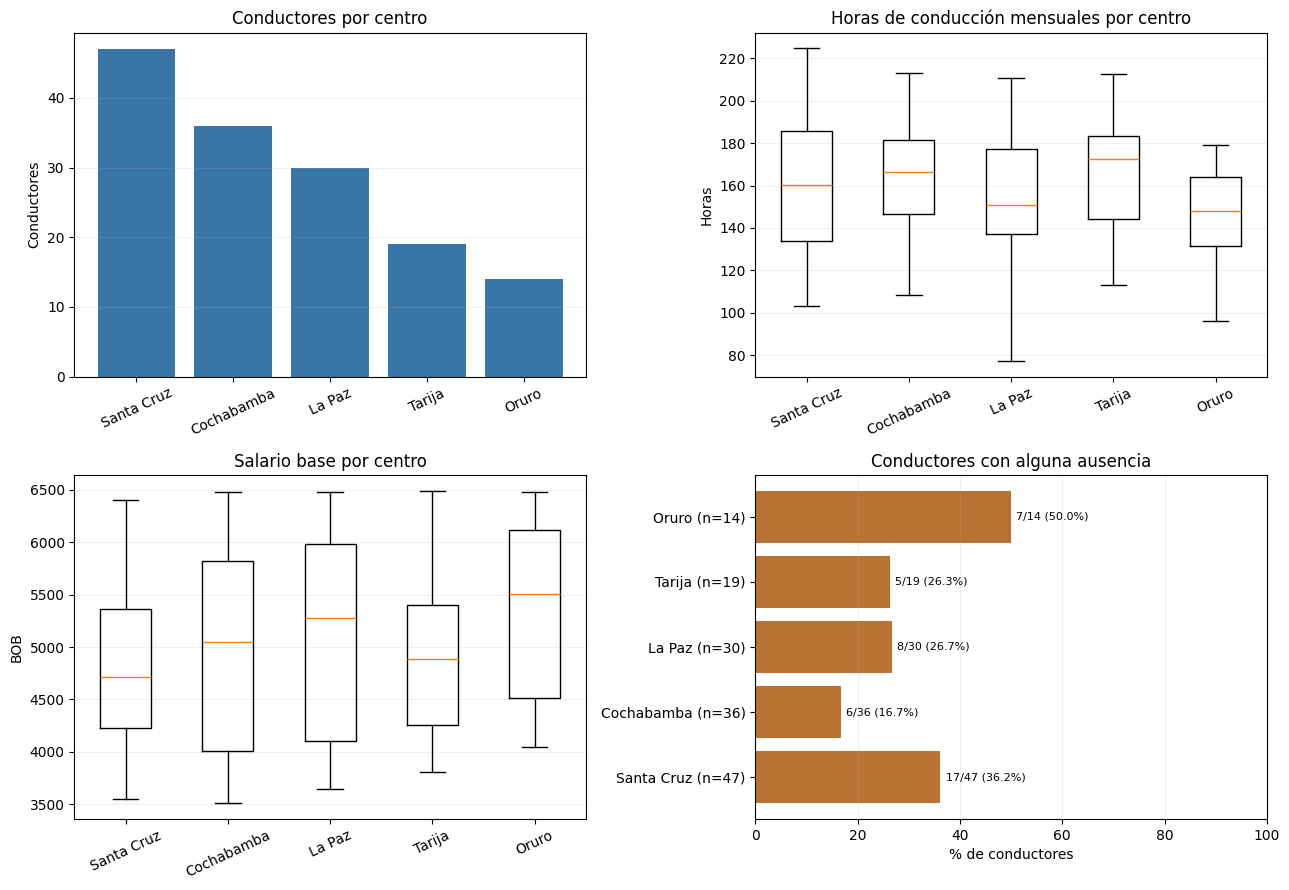

In [7]:
orden = tabla_centros.index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].bar(orden, tabla_centros.loc[orden,"conductores"], color="#3976A8")
axes[0,0].set_title("Conductores por centro")
axes[0,0].set_ylabel("Conductores")

series_horas = [df.loc[df["centro_distribucion"].eq(c), "horas_conduccion_mes"].to_numpy() for c in orden]
axes[0,1].boxplot(series_horas, labels=orden, showfliers=True)
axes[0,1].set_title("Horas de conducción mensuales por centro")
axes[0,1].set_ylabel("Horas")

series_salario = [df.loc[df["centro_distribucion"].eq(c), "salario_base_bob"].to_numpy() for c in orden]
axes[1,0].boxplot(series_salario, labels=orden, showfliers=True)
axes[1,0].set_title("Salario base por centro")
axes[1,0].set_ylabel("BOB")

etiquetas = [f"{c} (n={int(tabla_centros.loc[c,'conductores'])})" for c in orden]
barras_ausencia = axes[1,1].barh(etiquetas, tabla_centros.loc[orden,"pct_con_alguna_ausencia"], color="#B87333")
for barra, centro in zip(barras_ausencia, orden):
    fila = tabla_centros.loc[centro]
    axes[1,1].text(
        min(barra.get_width() + 1, 96), barra.get_y() + barra.get_height() / 2,
        f"{int(fila['conductores_con_ausencia'])}/{int(fila['conductores'])} ({fila['pct_con_alguna_ausencia']:.1f}%)",
        va="center", fontsize=8,
    )
axes[1,1].set_title("Conductores con alguna ausencia")
axes[1,1].set_xlabel("% de conductores")
axes[1,1].set_xlim(0, 100)

for ax in (axes[0,0], axes[0,1], axes[1,0]):
    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", alpha=0.2)
axes[1,1].grid(axis="x", alpha=0.2)
fig.tight_layout()
plt.show()


## 6 · Asociación exploratoria

La correlación resume asociación, no causalidad. Se calcula con los 146 registros disponibles en Silver, sin inferir que horas, salario o ausentismo provoquen cambios entre sí. Los centros pueden diferir en composición y condiciones de trabajo que este CSV no registra.


,horas_conduccion_mes,salario_base_bob,ausentismo_dias
horas_conduccion_mes,1.000,0.037,-0.064
salario_base_bob,0.037,1.000,-0.126
ausentismo_dias,-0.064,-0.126,1.000


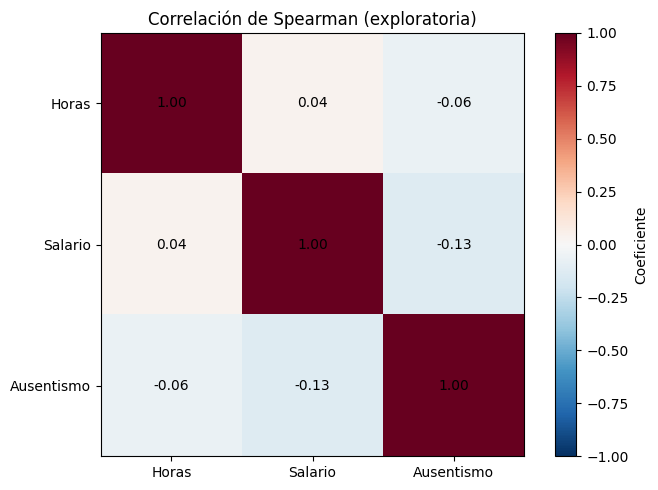

In [8]:
correlaciones = df[COLUMNAS_NUMERICAS].corr(method="spearman")
display(correlaciones.round(3))

fig, ax = plt.subplots(figsize=(7, 5))
imagen = ax.imshow(correlaciones.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(COLUMNAS_NUMERICAS)), ["Horas", "Salario", "Ausentismo"])
ax.set_yticks(range(len(COLUMNAS_NUMERICAS)), ["Horas", "Salario", "Ausentismo"])
for i in range(len(COLUMNAS_NUMERICAS)):
    for j in range(len(COLUMNAS_NUMERICAS)):
        ax.text(j, i, f"{correlaciones.iloc[i,j]:.2f}", ha="center", va="center")
ax.set_title("Correlación de Spearman (exploratoria)")
fig.colorbar(imagen, ax=ax, label="Coeficiente")
fig.tight_layout()
plt.show()


## 7 · Guía de interpretación

La síntesis anterior es automática y **solo descriptiva**. Completa los hallazgos **después de ejecutar** las tablas y gráficos. Para cada uno escribe: (1) qué se observa, (2) la cifra o gráfico que lo respalda, (3) qué decisión operativa podría orientar y (4) qué no se puede concluir todavía. No uses los datos para señalar personas concretas.

1. **Carga de conducción:** compara medianas y dispersión entre centros. ¿Cambian las conclusiones al mirar medianas en vez de medias?
2. **Ausentismo:** compara el porcentaje con alguna ausencia junto con `n`. ¿Qué información falta para hablar de una tasa de ausentismo comparable?
3. **Salario:** describe la variación por centro sin atribuirla a productividad, desempeño o discriminación. ¿Qué variables adicionales serían necesarias?
4. **Asociación:** si aparece una correlación, explica por qué no prueba causalidad.

**Limitaciones del CSV:** una sola fotografía mensual, sin fechas por conductor, turnos, días programados, antigüedad, tipo de contrato, rutas ni contexto operativo. Silver excluye filas en cuarentena, de modo que las conclusiones describen solo los registros utilizables. Este notebook no lee la cuarentena ni estima su efecto por centro.


## 8 · Validación de la interpretación

Las tablas deben cuadrar con Silver; el notebook no guarda datos ni gráficos por defecto. Las conclusiones redactadas deben basarse en los resultados de esta ejecución y no en cifras copiadas del laboratorio de clase.


In [9]:
assert len(df) == len(df_silver_raw)
assert df["chofer_id"].is_unique
assert "chofer_nombre" not in df.columns
assert tabla_centros["conductores"].sum() == len(df)
assert tabla_centros["conductores_con_ausencia"].sum() == int(df["ausentismo_dias"].gt(0).sum())
assert set(correlaciones.columns) == set(COLUMNAS_NUMERICAS)
assert tabla_centros["con_ausencia_n_de_N"].eq(
    tabla_centros["conductores_con_ausencia"].astype(int).astype(str) + "/" + tabla_centros["conductores"].astype(int).astype(str)
).all()
assert f"{len(df)} conductores utilizables" in sintesis_descriptiva
print("Validaciones de lectura y agregación correctas. Silver no fue modificado.")


Validaciones de lectura y agregación correctas. Silver no fue modificado.
